In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sb 

In [2]:
df = pd.read_csv("/Users/PUSHPAK/OneDrive/Desktop/Spain_Project/data/normalized_2_songs.csv")

In [3]:
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,duration_min,song_id
0,2025-06-02,40,0 confianza,rvfv,35,217500,album,20,False,3.625,0 confianza_rvfv
1,2025-06-05,31,0 confianza,rvfv,57,217500,album,20,False,3.625,0 confianza_rvfv
2,2025-06-06,25,0 confianza,rvfv,57,217500,album,20,False,3.625,0 confianza_rvfv
3,2025-06-07,23,0 confianza,rvfv,57,217500,album,20,False,3.625,0 confianza_rvfv
4,2025-06-08,23,0 confianza,rvfv,57,217500,album,20,False,3.625,0 confianza_rvfv


In [4]:
df.isnull().sum()

date            0
position        0
song            0
artist          0
popularity      0
duration_ms     0
album_type      0
total_tracks    0
is_explicit     0
duration_min    0
song_id         0
dtype: int64

In [5]:
df['song_id'].nunique()

575

In [6]:
df.groupby('date').size().value_counts()

50    554
Name: count, dtype: int64

In [7]:
lifecycle = df.groupby('song_id').agg(
    entry_date=('date','min'),
    exit_date=('date','max'),
    peak_position=('position','min'),
    days_on_playlist=('date','count')
).reset_index()

In [8]:
lifecycle

,song_id,entry_date,exit_date,peak_position,days_on_playlist
0,0 confianza_rvfv,2025-06-02,2025-06-23,23,20
1,"1 de enero, puntacana_rels b",2025-04-28,2025-04-28,45,1
2,1000cosas_lola indigo & manuel turizo,2025-03-10,2025-11-13,3,245
3,100xciento_foreign teck & eladio carrion & de ...,2025-04-30,2025-05-15,13,11
4,14 febreros_quevedo,2025-11-24,2025-11-27,9,4
...,...,...,...,...,...
570,yo sé_yan block & torrres,2025-11-01,2025-11-27,8,26
571,yo tengo un novio_lola indigo,2024-12-17,2024-12-24,18,8
572,yotuloko_omar montes & rels b,2025-07-14,2025-11-05,22,114
573,"young miko: bzrp music sessions, vol. 58_bizar...",2025-01-13,2025-04-26,1,100


In [9]:
lifecycle['entry_date'] = pd.to_datetime(lifecycle['entry_date'])
lifecycle['exit_date'] = pd.to_datetime(lifecycle['exit_date'])

In [10]:
lifecycle['lifetime_days'] = (
    lifecycle['exit_date'] - lifecycle['entry_date']
).dt.days + 1

In [11]:
lifecycle.dtypes

song_id                     object
entry_date          datetime64[ns]
exit_date           datetime64[ns]
peak_position                int64
days_on_playlist             int64
lifetime_days                int64
dtype: object

In [12]:
# Overview of data 
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print("Unique songs:", df['song_id'].nunique())
print("Unique artists:", df['artist'].nunique())
print("Date range:", df['date'].min(), "to", df['date'].max())

Total rows: 27700
Total columns: 11
Unique songs: 575
Unique artists: 301
Date range: 2024-05-18 to 2025-11-27


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'saiko'),
  Text(1, 0, 'myke towers'),
  Text(2, 0, 'quevedo'),
  Text(3, 0, 'karol g'),
  Text(4, 0, 'bad bunny'),
  Text(5, 0, 'mora'),
  Text(6, 0, 'dei v'),
  Text(7, 0, 'feid'),
  Text(8, 0, 'rauw alejandro'),
  Text(9, 0, 'manuel turizo')])

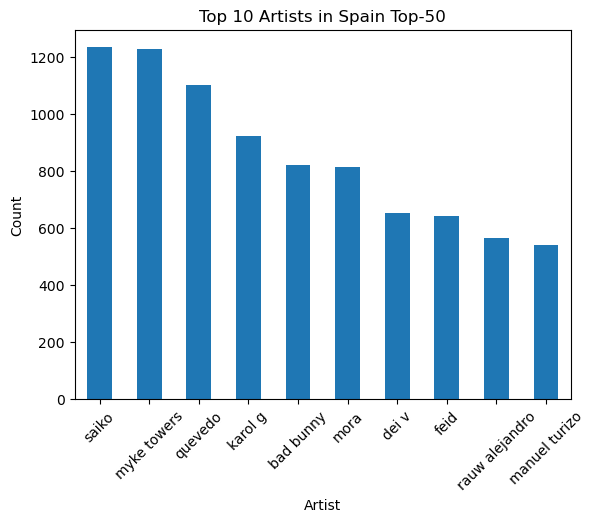

In [13]:
#EDA Top Artists Analysis
top_artists = df['artist'].value_counts().head(10)

top_artists.plot(kind='bar')
plt.title("Top 10 Artists in Spain Top-50")
plt.xlabel("Artist")
plt.ylabel("Count")
plt.xticks(rotation=45)

Text(0, 0.5, 'Frequency')

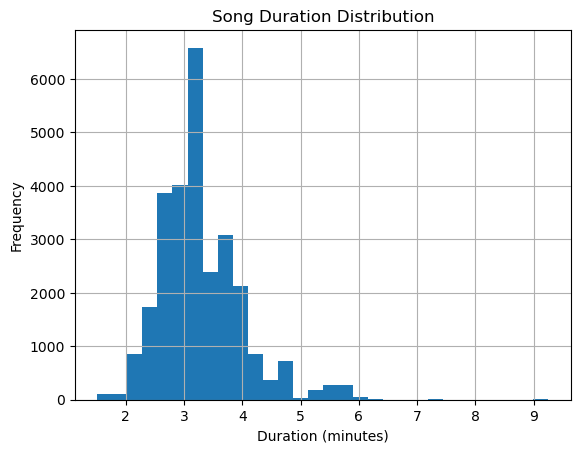

In [14]:
#Song Duration Distribution
df['duration_min'].hist(bins=30)
plt.title("Song Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

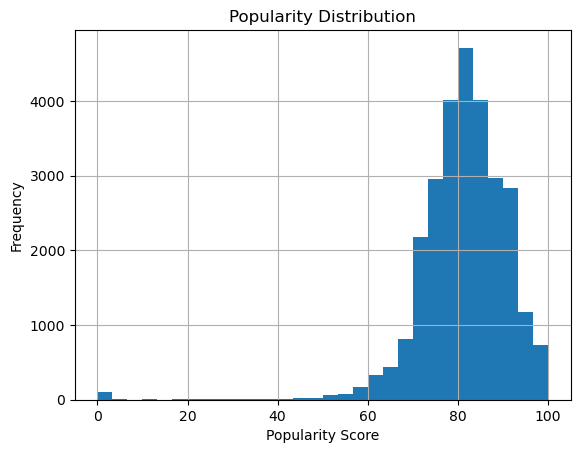

In [15]:
# Popularity Distribution
df['popularity'].hist(bins=30)
plt.title("Popularity Distribution")
plt.xlabel("Popularity Score")
plt.ylabel("Frequency")

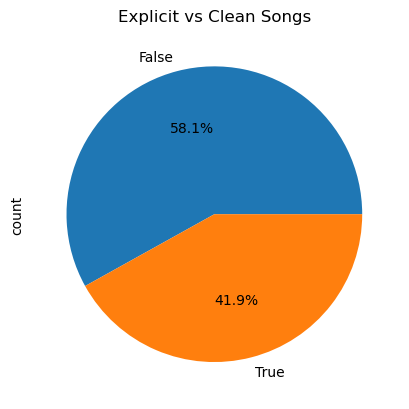

In [16]:
# Explicit vs Clean Songs
df['is_explicit'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Explicit vs Clean Songs")
plt.show()

Text(0, 0.5, 'Count')

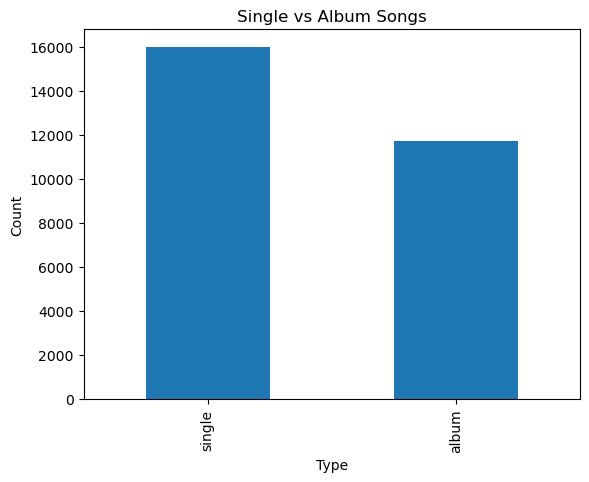

In [17]:
# Album Type Distribution
df['album_type'].value_counts().plot(kind='bar')
plt.title("Single vs Album Songs")
plt.xlabel("Type")
plt.ylabel("Count")


Text(0, 0.5, 'Average Popularity')

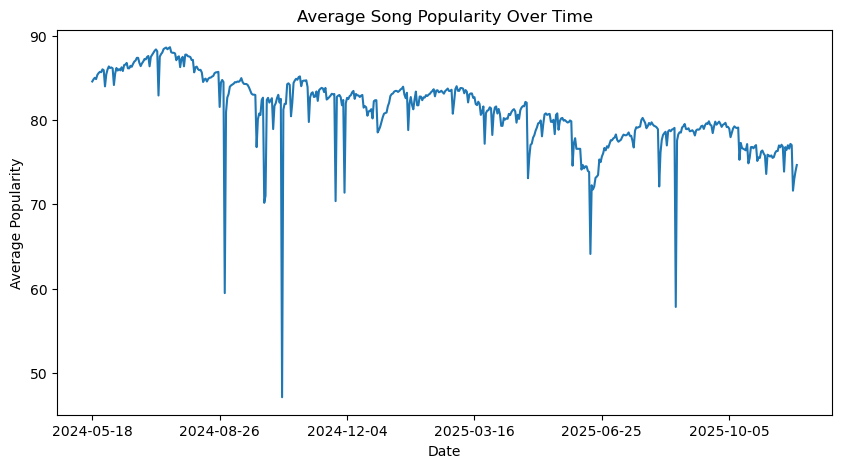

In [18]:
# Average Position Over Time
daily_popularity = df.groupby('date')['popularity'].mean()

plt.figure(figsize=(10,5))
daily_popularity.plot()
plt.title("Average Song Popularity Over Time")
plt.xlabel("Date")
plt.ylabel("Average Popularity")

Text(0.5, 1.0, 'Playlist Churn Over Time')

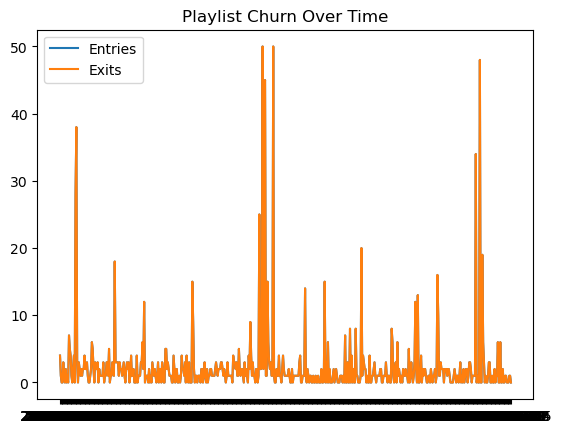

In [19]:
# To Measure how playlist changes daily
df_sorted = df.sort_values(by='date')

dates = df['date'].unique()
entries = []
exits = []

for i in range(1, len(dates)):
    prev = set(df[df['date']==dates[i-1]]['song_id'])
    curr = set(df[df['date']==dates[i]]['song_id'])
    
    entries.append(len(curr - prev))
    exits.append(len(prev - curr))

plt.plot(dates[1:], entries, label='Entries')
plt.plot(dates[1:], exits, label='Exits')
plt.legend()
plt.title("Playlist Churn Over Time")

Text(0, 0.5, 'Number of Songs')

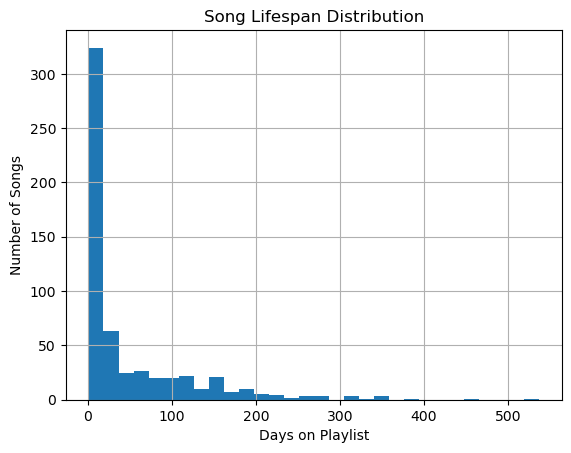

In [20]:
# Lifecycle Distribution
lifecycle['days_on_playlist'].hist(bins=30)
plt.title("Song Lifespan Distribution")
plt.xlabel("Days on Playlist")
plt.ylabel("Number of Songs")

In [21]:
# KPI 1 — Average Days on Playlist
avg_days_on_playlist = lifecycle['days_on_playlist'].mean()
print("Average Days on Playlist:", round(avg_days_on_playlist, 2))

Average Days on Playlist: 48.17


In [22]:
# KPI 2 — Entry-to-Peak Time

# Step 1 — Find Peak Date
peak_dates = df.loc[df.groupby('song_id')['position'].idxmin()][['song_id', 'date']]
peak_dates.rename(columns={'date': 'peak_date'}, inplace=True)

# Step 2 — Merge with Lifecycle
lifecycle = lifecycle.merge(peak_dates, on='song_id', how='left')

# Step 3 — Convert Dates Properly
lifecycle['entry_date'] = pd.to_datetime(lifecycle['entry_date'])
lifecycle['peak_date'] = pd.to_datetime(lifecycle['peak_date'])

# Step 4 — Calculate Entry-to-Peak Time
lifecycle['entry_to_peak_days'] = (lifecycle['peak_date'] - lifecycle['entry_date']).dt.days

# Step 5 — KPI Value
avg_entry_to_peak = lifecycle['entry_to_peak_days'].mean()
print("Average Entry-to-Peak Time:", round(avg_entry_to_peak, 2))

Average Entry-to-Peak Time: 9.48


In [23]:
# KPI 3 — Playlist Churn Rate
dates = sorted(df['date'].unique())
entries = []
exits = []

for i in range(1, len(dates)):
    prev = set(df[df['date'] == dates[i-1]]['song_id'])
    curr = set(df[df['date'] == dates[i]]['song_id'])
    
    entries.append(len(curr - prev))
    exits.append(len(prev - curr))

avg_churn_rate = (sum(entries) + sum(exits)) / (2 * len(entries))
print("Average Playlist Churn Rate:", round(avg_churn_rate, 2))

Average Playlist Churn Rate: 1.72


In [24]:
# KPI 4 — Retention Stability Index
stability = df.groupby('song_id')['position'].std().reset_index()
stability.rename(columns={'position': 'position_std'}, inplace=True)

avg_stability_index = stability['position_std'].mean()
print("Average Retention Stability Index:", round(avg_stability_index, 2))

Average Retention Stability Index: 8.44


In [25]:
# KPI 5 — Explicit Content Lifecycle Score

# Step 1 — Add Explicit Info to Lifecycle
explicit_info = df.groupby('song_id')['is_explicit'].first().reset_index()
lifecycle = lifecycle.merge(explicit_info, on='song_id', how='left')

# Step 2 — Compare Average Days
explicit_lifecycle = lifecycle.groupby('is_explicit')['days_on_playlist'].mean()
print("Average Days (Clean Songs):", round(explicit_lifecycle[False], 2))
print("Average Days (Explicit Songs):", round(explicit_lifecycle[True], 2))

Average Days (Clean Songs): 50.17
Average Days (Explicit Songs): 45.58


In [26]:
# KPI 6 — Single vs Album Longevity Ratio

# Step 1 — Add Album Type to Lifecycle
album_info = df.groupby('song_id')['album_type'].first().reset_index()
lifecycle = lifecycle.merge(album_info, on='song_id', how='left')

# Step 2 — Compare Average Days
album_longevity = lifecycle.groupby('album_type')['days_on_playlist'].mean()
print("Average Days (Single):", round(album_longevity['single'], 2))
print("Average Days (Album):", round(album_longevity['album'], 2))

Average Days (Single): 58.57
Average Days (Album): 38.1


In [27]:
# KPI 7 — Peak Position Average
avg_peak_position = lifecycle['peak_position'].mean()
print("Average Peak Position:", round(avg_peak_position, 2))

Average Peak Position: 21.79


In [28]:
df.to_csv("spotify_spain_top50_cleaned.csv", index=False)

In [29]:
explicit_info = df.groupby('song_id')['is_explicit'].first().reset_index()
album_info = df.groupby('song_id')['album_type'].first().reset_index()

lifecycle = lifecycle.merge(explicit_info, on='song_id', how='left')
lifecycle = lifecycle.merge(album_info, on='song_id', how='left')

lifecycle['entry_date'] = pd.to_datetime(lifecycle['entry_date'])
lifecycle['exit_date'] = pd.to_datetime(lifecycle['exit_date'])
lifecycle['peak_date'] = pd.to_datetime(lifecycle['peak_date'])

lifecycle['entry_to_peak_days'] = (
    lifecycle['peak_date'] - lifecycle['entry_date']
).dt.days

lifecycle['lifetime_days'] = (
    lifecycle['exit_date'] - lifecycle['entry_date']
).dt.days + 1

lifecycle.to_csv("spotify_spain_lifecycle.csv", index=False)

In [30]:
# Recreate lifecycle properly
lifecycle = df.groupby('song_id').agg(
    entry_date=('date', 'min'),
    exit_date=('date', 'max'),
    peak_position=('position', 'min'),
    days_on_playlist=('date', 'count')
).reset_index()

# Peak date
peak_dates = df.loc[df.groupby('song_id')['position'].idxmin()][['song_id', 'date']]
peak_dates.rename(columns={'date': 'peak_date'}, inplace=True)

# Merge peak date
lifecycle = lifecycle.merge(peak_dates, on='song_id', how='left')

# Add explicit info
explicit_info = df.groupby('song_id')['is_explicit'].first().reset_index()
lifecycle = lifecycle.merge(explicit_info, on='song_id', how='left')

# Add album type
album_info = df.groupby('song_id')['album_type'].first().reset_index()
lifecycle = lifecycle.merge(album_info, on='song_id', how='left')

# Convert dates
lifecycle['entry_date'] = pd.to_datetime(lifecycle['entry_date'])
lifecycle['exit_date'] = pd.to_datetime(lifecycle['exit_date'])
lifecycle['peak_date'] = pd.to_datetime(lifecycle['peak_date'])

# Entry to peak
lifecycle['entry_to_peak_days'] = (
    lifecycle['peak_date'] - lifecycle['entry_date']
).dt.days

# Lifetime days
lifecycle['lifetime_days'] = (
    lifecycle['exit_date'] - lifecycle['entry_date']
).dt.days + 1

# Save corrected lifecycle CSV
lifecycle.to_csv("spotify_spain_lifecycle.csv", index=False)

print(lifecycle.head())
print(lifecycle.columns)

                                             song_id entry_date  exit_date  \
0                                   0 confianza_rvfv 2025-06-02 2025-06-23   
1                       1 de enero, puntacana_rels b 2025-04-28 2025-04-28   
2              1000cosas_lola indigo & manuel turizo 2025-03-10 2025-11-13   
3  100xciento_foreign teck & eladio carrion & de ... 2025-04-30 2025-05-15   
4                                14 febreros_quevedo 2025-11-24 2025-11-27   

   peak_position  days_on_playlist  peak_date  is_explicit album_type  \
0             23                20 2025-06-07        False      album   
1             45                 1 2025-04-28        False      album   
2              3               245 2025-03-10        False     single   
3             13                11 2025-05-11         True     single   
4              9                 4 2025-11-24         True      album   

   entry_to_peak_days  lifetime_days  
0                   5             22  
1             

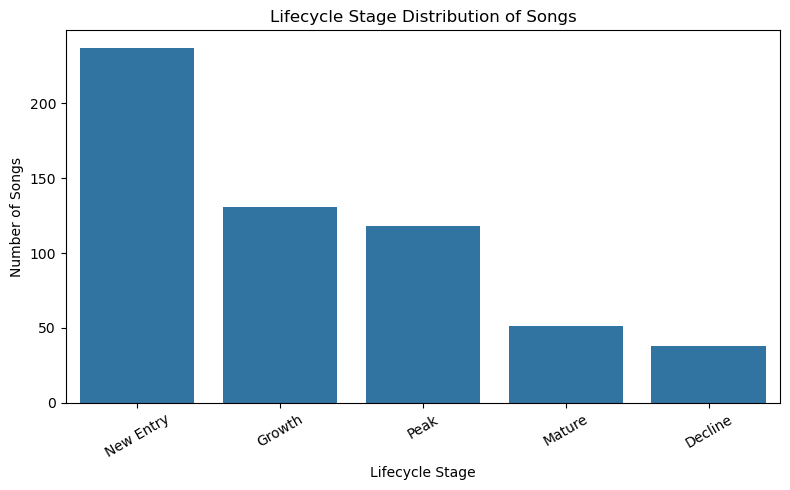

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create lifecycle stage (if not already created)
def classify_stage(row):
    if row['days_on_playlist'] <= 7:
        return "New Entry"
    elif row['days_on_playlist'] <= 30:
        return "Growth"
    elif row['peak_position'] <= 10:
        return "Peak"
    elif row['days_on_playlist'] <= 90:
        return "Mature"
    else:
        return "Decline"

lifecycle['lifecycle_stage'] = lifecycle.apply(classify_stage, axis=1)

# Count stages in order
order = ['New Entry', 'Growth', 'Peak', 'Mature', 'Decline']
stage_counts = lifecycle['lifecycle_stage'].value_counts().reindex(order)

# Plot graph
plt.figure(figsize=(8,5))
sns.barplot(x=stage_counts.index, y=stage_counts.values)

plt.title("Lifecycle Stage Distribution of Songs")
plt.xlabel("Lifecycle Stage")
plt.ylabel("Number of Songs")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("lifecycle_stage_distribution.png", dpi=300)
plt.show()